FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

Objective:
Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data provided in the exchange_rate.csv
dataset. 

Dataset:
The dataset contains historical exchange rate with each column representing a different currency rate over time. 
    The first column indicates the date, and the second column represents exchange rates USD to Australian Dollar.

Part 1: Data Preparation and Exploration
1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.
2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.
3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.

In [102]:
import pandas as pd
import numpy as np

In [103]:
df=pd.read_csv('exchange_rate.csv')

In [104]:
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [106]:
df.shape

(7588, 2)

In [107]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [108]:
df.isnull().sum()

date       0
Ex_rate    0
dtype: int64

In [109]:
df[df.duplicated]

,date,Ex_rate


In [110]:
df.set_index('date',inplace=True)

In [111]:
df.head()

,Ex_rate
date,
01-01-1990 00:00,0.7855
02-01-1990 00:00,0.7818
03-01-1990 00:00,0.7867
04-01-1990 00:00,0.7860
05-01-1990 00:00,0.7849


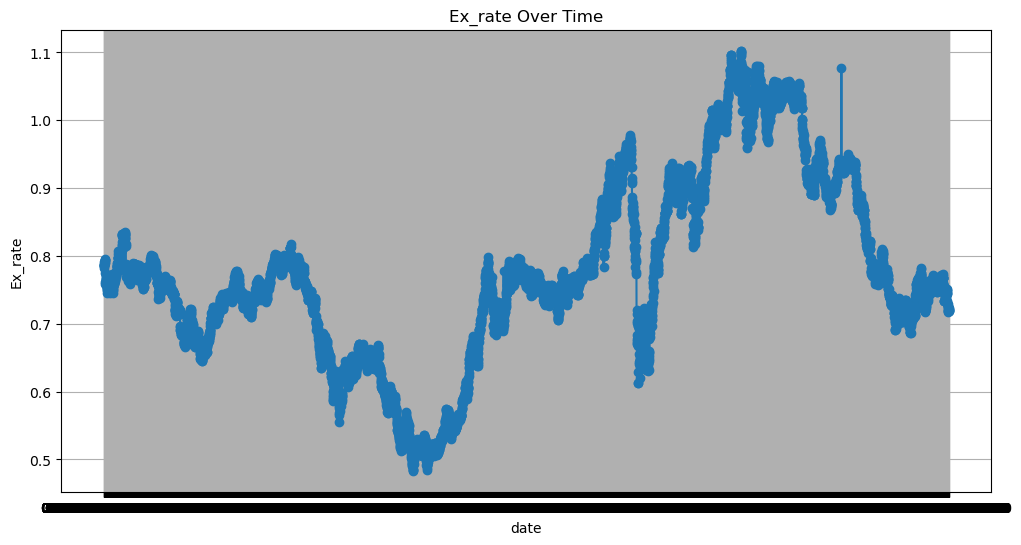

In [112]:
# Plot Ex_rate over time
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(df, marker='o')
plt.title('Ex_rate Over Time')
plt.xlabel('date')
plt.ylabel('Ex_rate')
plt.grid(True)
plt.show()


(array([ 413.,  401.,  709., 1002., 2576.,  463.,  643.,  565.,  484.,
         332.]),
 array([0.483297 , 0.5452209, 0.6071448, 0.6690687, 0.7309926, 0.7929165,
        0.8548404, 0.9167643, 0.9786882, 1.0406121, 1.102536 ]),
 <BarContainer object of 10 artists>)

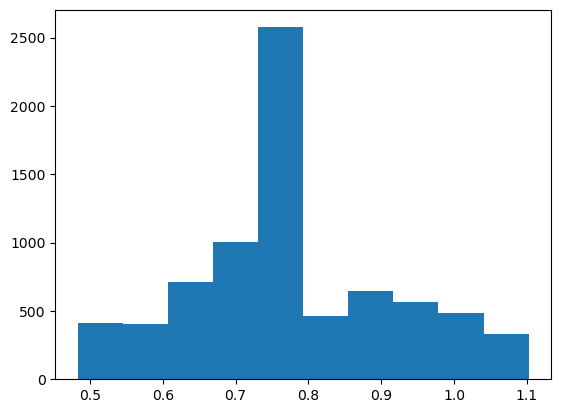

In [113]:
plt.hist(df['Ex_rate'])

Part 2: Model Building - ARIMA
1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.
2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.
3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.
4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.

In [114]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.model_selection import ParameterGrid

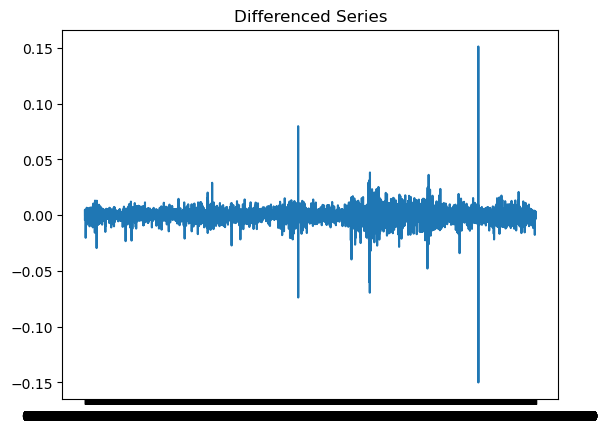

In [115]:
df_diff = df['Ex_rate'].diff().dropna()

plt.plot(df_diff)
plt.title("Differenced Series")
plt.show()

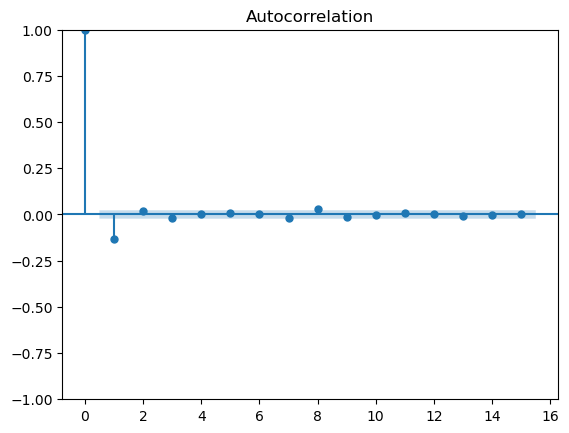

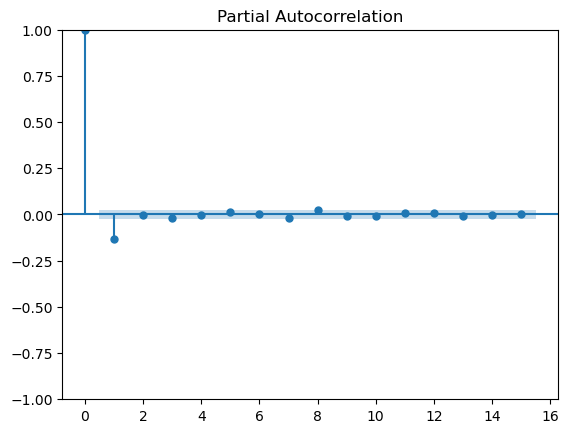

In [116]:
import statsmodels.graphics.tsaplots as tsa_plots
tsa_plots.plot_acf(df_diff, lags=15)
tsa_plots.plot_pacf(df_diff, lags=15)
plt.show()

In [117]:
from statsmodels.tsa.arima.model import ARIMA

In [118]:
arima=ARIMA(df['Ex_rate'],order=(1,1,1))
arima_fit=arima.fit()

C:\Users\ACRE\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\ACRE\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\ACRE\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [119]:
summary=arima_fit.summary()
summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Wed, 01 Apr 2026   AIC                         -56102.322
Time:                        12:07:28   BIC                         -56081.519
Sample:                             0   HQIC                        -56095.182
                               - 7588                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.000    3.58e-05    3.62e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):           2865078.33
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.97   Skew:                             0.24
Prob(H) (two-sided):                  0.00   Kurtosis:                        98.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [120]:
print("AIC: ",arima_fit.aic)
print("BIC: ",arima_fit.bic)

AIC:  -56102.32167281932
BIC:  -56081.519098213306


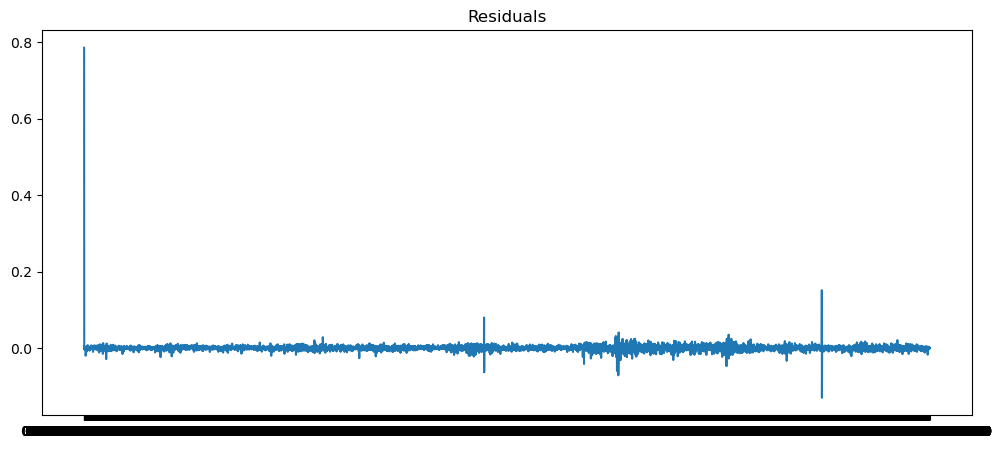

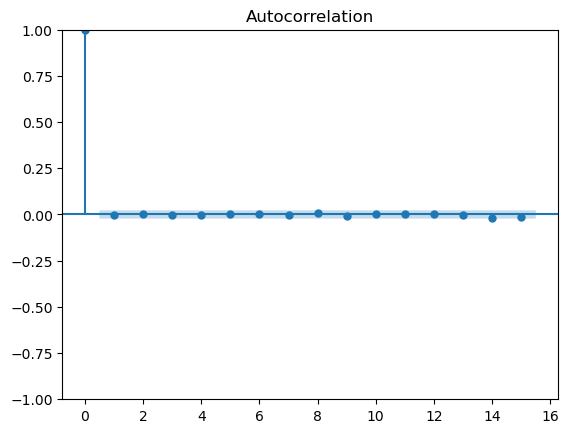

In [121]:
residuals = arima_fit.resid

plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

tsa_plots.plot_acf(residuals, lags=15)
plt.show()

C:\Users\ACRE\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ACRE\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


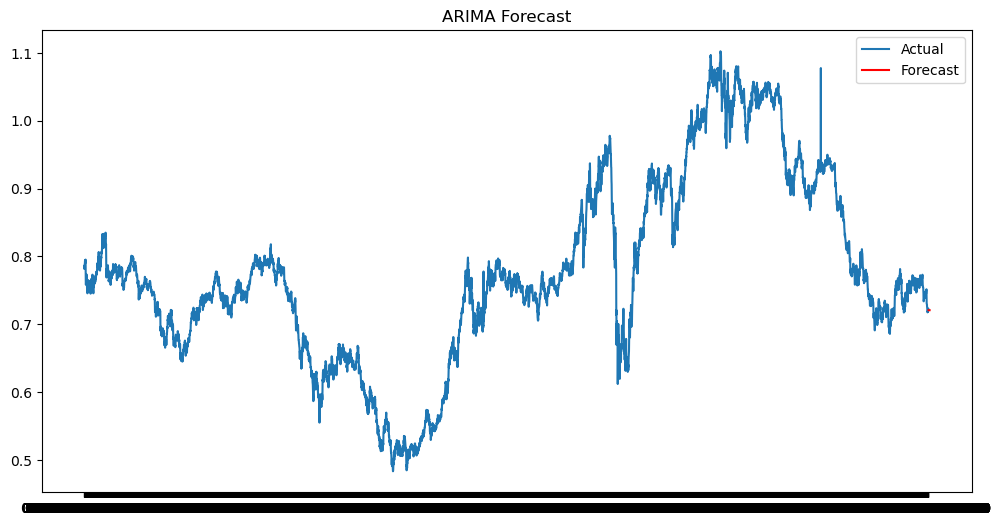

In [122]:
forecast = arima_fit.forecast(steps=10)

plt.figure(figsize=(12,6))
plt.plot(df['Ex_rate'], label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

In [123]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [124]:
model_es = ExponentialSmoothing(df['Ex_rate'], trend='add', seasonal=None)
fit_es = model_es.fit()

C:\Users\ACRE\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


C:\Users\ACRE\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ACRE\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


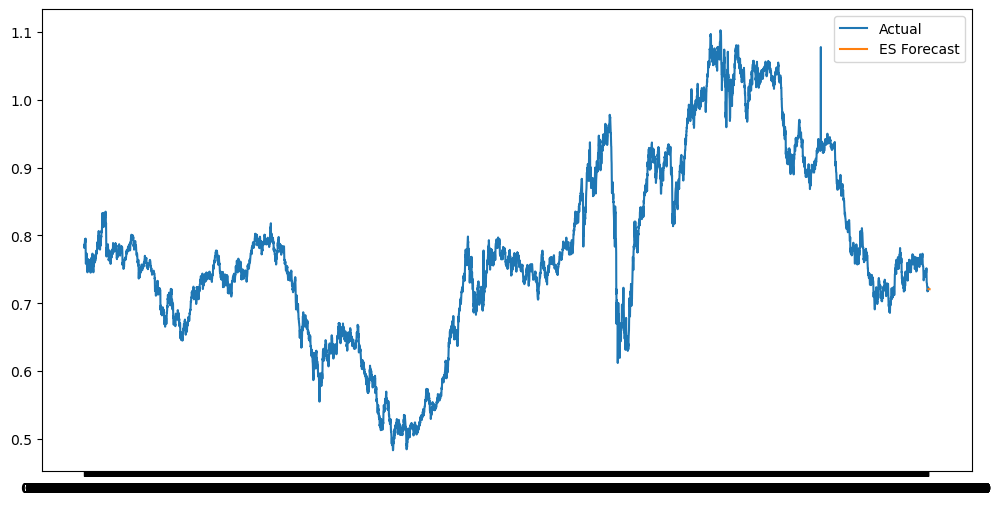

In [125]:
forecast_es = fit_es.forecast(10)

plt.figure(figsize=(12,6))
plt.plot(df['Ex_rate'], label='Actual')
plt.plot(forecast_es, label='ES Forecast')
plt.legend()
plt.show()

In [143]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df[['Ex_rate']])

In [150]:
training_size = int(len(scaled_data) * 0.7)
test_size = len(scaled_data) - training_size

train_data = scaled_data[0:training_size]
test_data = scaled_data[training_size:]

In [151]:
time_step = 12

In [153]:
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [155]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [156]:
def create_dataset(dataset, time_step=12):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:(i + time_step), 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

In [157]:
param_grid = {
    'units': [32, 50, 64],
    'batch_size': [16, 32],
    'epochs': [10, 20]
}

In [ ]:
best_score = float('inf')
best_params = None

for params in ParameterGrid(param_grid):
    
    model = Sequential()
    model.add(LSTM(units=params['units'], return_sequences=False, input_shape=(time_step, 1)))
    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    model.fit(X_train, y_train,
              epochs=params['epochs'],
              batch_size=params['batch_size'],
              verbose=0)
    
    # Evaluate on validation/test
    pred = model.predict(X_test)
    
    from sklearn.metrics import mean_squared_error
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    
    if rmse < best_score:
        best_score = rmse
        best_params = params

Hyperparameter tuning was performed using Grid Search to identify the optimal combination of parameters such as number of LSTM units, batch size, and number of epochs.
Multiple combinations were evaluated based on RMSE, and the model with the lowest error was selected as the final model.
This step helps improve model performance and ensures better forecasting accuracy.

In [159]:
print("Best Parameters:", best_params)
print("Best RMSE:", best_score)

Best Parameters: {'batch_size': 16, 'epochs': 20, 'units': 64}
Best RMSE: 0.011373428699571609


In [160]:
best_model = Sequential()
best_model.add(LSTM(units=best_params['units'], input_shape=(time_step,1)))
best_model.add(Dense(1))

best_model.compile(optimizer='adam', loss='mean_squared_error')

best_model.fit(X_train, y_train,
               epochs=best_params['epochs'],
               batch_size=best_params['batch_size'])

Epoch 1/20


C:\Users\ACRE\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


332/332 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0040
Epoch 2/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3.0643e-04
Epoch 3/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.9462e-04
Epoch 4/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.6543e-04
Epoch 5/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2.4829e-04
Epoch 6/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.1868e-04
Epoch 7/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2.1451e-04
Epoch 8/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.8206e-04
Epoch 9/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.7557e-04
Epoch 10/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.6373e-04
Epoch 11/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.5529e-04
Epoch 12/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.4774e-04
Epoch 13/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.3570e-04
Epoch 14/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.2180e-04
Epoch 15/20
332/

Part 3: Evaluation and Comparison
1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.
2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.
3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.

In [161]:
# Calculate RMSE using the fitted values and original data
from sklearn.metrics import root_mean_squared_error
import numpy as np
rmse = root_mean_squared_error(df['Ex_rate'], arima_fit.fittedvalues)
print("RMSE:",rmse)

RMSE: 0.010828926684741193


In [162]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ARIMA
mae_arima = mean_absolute_error(df['Ex_rate'], arima_fit.fittedvalues)
rmse_arima = np.sqrt(mean_squared_error(df['Ex_rate'], arima_fit.fittedvalues))
mape_arima = np.mean(np.abs((df['Ex_rate'] - arima_fit.fittedvalues) / df['Ex_rate'])) * 100

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)
print("ARIMA MAPE:", mape_arima)

ARIMA MAE: 0.0037958716561923883
ARIMA RMSE: 0.010828926684741193
ARIMA MAPE: 0.4951354201577679


In [163]:
mae_es = mean_absolute_error(df['Ex_rate'], fit_es.fittedvalues)
rmse_es = np.sqrt(mean_squared_error(df['Ex_rate'], fit_es.fittedvalues))
mape_es = np.mean(np.abs((df['Ex_rate'] - fit_es.fittedvalues) / df['Ex_rate'])) * 100

print("ES MAE:", mae_es)
print("ES RMSE:", rmse_es)
print("ES MAPE:", mape_es)

ES MAE: 0.003692539980269651
ES RMSE: 0.0059965782393957045
ES MAPE: 0.4819525367199166


Conclusion:

- ARIMA captures time dependency using lag values.
- Exponential Smoothing captures trend effectively.
- ARIMA is better for complex patterns, while ES is simpler and faster.